In [57]:
%pip install pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [58]:
%pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
df = pd.read_csv("superstore.csv")

In [61]:
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,00:00.0,CA-2011-130813,High,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,00:00.0,CA-2011-148614,Medium,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,00:00.0,CA-2011-118962,Medium,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,00:00.0,CA-2011-118962,Medium,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,00:00.0,CA-2011-146969,High,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [62]:
df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID',
       'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='str')

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  str    
 1   City            51290 non-null  str    
 2   Country         51290 non-null  str    
 3   Customer.ID     51290 non-null  str    
 4   Customer.Name   51290 non-null  str    
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  str    
 7   Order.Date      51290 non-null  str    
 8   Order.ID        51290 non-null  str    
 9   Order.Priority  51290 non-null  str    
 10  Product.ID      51290 non-null  str    
 11  Product.Name    51290 non-null  str    
 12  Profit          51290 non-null  float64
 13  Quantity        51290 non-null  int64  
 14  Region          51290 non-null  str    
 15  Row.ID          51290 non-null  int64  
 16  Sales           51290 non-null  int64  
 17  Segment         51290 non-null  str    
 1

In [64]:
df.describe()

,Discount,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


Converting to dates

In [65]:
df["Order.Date"] = pd.to_datetime(df["Order.Date"])
df["Ship.Date"] = pd.to_datetime(df["Ship.Date"])

In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        51290 non-null  str           
 1   City            51290 non-null  str           
 2   Country         51290 non-null  str           
 3   Customer.ID     51290 non-null  str           
 4   Customer.Name   51290 non-null  str           
 5   Discount        51290 non-null  float64       
 6   Market          51290 non-null  str           
 7   Order.Date      51290 non-null  datetime64[us]
 8   Order.ID        51290 non-null  str           
 9   Order.Priority  51290 non-null  str           
 10  Product.ID      51290 non-null  str           
 11  Product.Name    51290 non-null  str           
 12  Profit          51290 non-null  float64       
 13  Quantity        51290 non-null  int64         
 14  Region          51290 non-null  str           
 15  Row.ID       

In [67]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
avg_discount = df["Discount"].mean()

print("Overall Key Performance Indicators (KPI's)")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Average Discount: {avg_discount:.2%}")

Overall Key Performance Indicators (KPI's)
Total Sales: $12,642,905.00
Total Profit: $1,467,457.29
Average Discount: 14.29%


In [68]:
df["Profit_Margin"] = df["Profit"] / df["Sales"]
df["Profit_Margin"].mean()

np.float64(-inf)

A sale is $0 so can't divide by zero. Solution: Look how many are zero. Convert it to Nan

In [69]:
df[df["Sales"] == 0]

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum,Profit_Margin
46158,Office Supplies,Houston,United States,ZC-219104,Zuschuss Carroll,0.8,US,2026-02-20,US-2014-102288,Medium,...,Consumer,2026-02-20,Standard Class,0.01,Texas,Appliances,2014,North America,25,-inf


In [70]:
df["Profit_Margin"] = np.where(
    df["Sales"] != 0,
    df["Profit"] / df["Sales"],
    0
)

print(f"Profit Margin after handling zero sales: {df['Profit_Margin'].mean() * 100:.2f}%")

Profit Margin after handling zero sales: 4.72%


So on average:
For every $1 of sales, the company keeps about $0.047 (4.7 cents) as profit.
That’s fairly thin.

In [71]:
df["Profit_Margin"].describe()

count    51290.000000
mean         0.047199
std          0.466845
min         -4.727752
25%          0.000000
50%          0.169249
75%          0.333111
max          0.582800
Name: Profit_Margin, dtype: float64

Standard Deviation: 0.4668, large compared to the mean, profit margins very a lot. Some are huge profits, and some are big losses.

Minimum: -472% profit margin, a very big loss- could be from a refund or return? 

50% (Median): Larger than mean, so the large loss transactions are pulling the average down. 

In [72]:
df.groupby("Category")["Profit_Margin"].mean()

Category
Furniture          0.008705
Office Supplies    0.058557
Technology         0.049658
Name: Profit_Margin, dtype: float64

Furniture is high risk — thin margins make losses from discounts or shipping very impactful.

Office Supplies and Technology are better but still only 5–6% margin.

Overall portfolio is low-margin (mean 4.7%), consistent with retail, but highlights that discounts or returns can drastically hurt profitability.

In [73]:
# Create 5 discount bins (0%, 0–10%, 10–20%, etc.)
df["Discount_Bin"] = pd.cut(df["Discount"], bins=[-0.01, 0.1, 0.2, 0.3, 0.5, 1.0],
                             labels=["0-10%", "10-20%", "20-30%", "30-50%", "50%+"])

In [74]:
category_discount_margin = df.groupby(["Category", "Discount_Bin"])["Profit_Margin"].mean().reset_index()
category_discount_margin

,Category,Discount_Bin,Profit_Margin
0,Furniture,0-10%,0.238771
1,Furniture,10-20%,0.061810
2,Furniture,20-30%,-0.041800
3,Furniture,30-50%,-0.317520
4,Furniture,50%+,-1.075029
5,Office Supplies,0-10%,0.259648
6,Office Supplies,10-20%,0.186871
7,Office Supplies,20-30%,-0.058425
8,Office Supplies,30-50%,-0.349772
9,Office Supplies,50%+,-1.167357


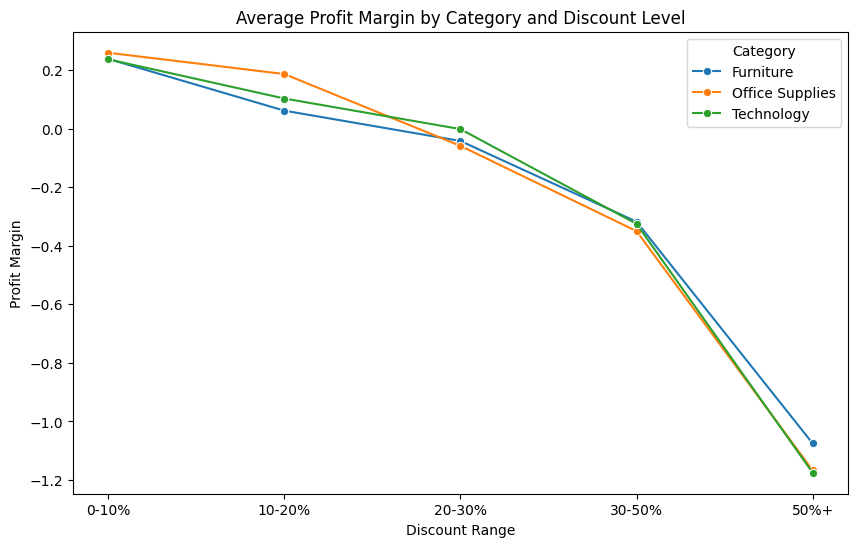

In [75]:
plt.figure(figsize=(10,6))
sns.lineplot(data=category_discount_margin, x="Discount_Bin", y="Profit_Margin", hue="Category", marker="o")
plt.title("Average Profit Margin by Category and Discount Level")
plt.ylabel("Profit Margin")
plt.xlabel("Discount Range")
plt.show()

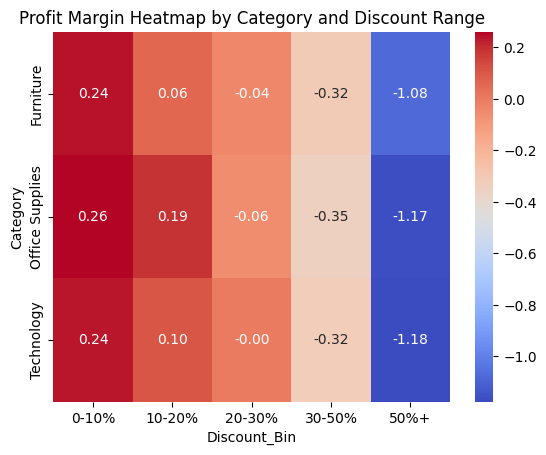

In [76]:
pivot_table = category_discount_margin.pivot(index="Category", columns="Discount_Bin", values="Profit_Margin")
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Profit Margin Heatmap by Category and Discount Range")
plt.show()

Discount Sensitivity is Extreme:
Margins go from 24–26% to -100%+ with extreme discounts.

Category Differences:
Furniture is very risky, can highlight as strategic recommendation for pricing strategy.
Office Supplies and Technology are slightly more resilient at lower discounts.

Actionable Recommendations:
Limit discounts >30% across categories.
Monitor Furniture and Technology closely for losses during promotions.
Consider alternative promotions (bundling, loyalty programs) instead of steep discounts.

Regional Analysis

In [77]:
region_summary = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values(by="Sales", ascending=False)
region_summary

,Sales,Profit
Region,,
Central,2822399,311403.98164
South,1600960,140355.76618
North,1248192,194597.95252
Oceania,1100207,120089.11200
Southeast Asia,884438,17852.32900
North Asia,848349,165578.42100
EMEA,806184,43897.97100
Africa,783776,88871.63100
Central Asia,752839,132480.18700


In [78]:
region_margin = df.groupby("Region")["Profit_Margin"].mean().sort_values(ascending=False)
region_margin

Region
Canada            0.247431
West              0.219441
North Asia        0.179520
East              0.167169
Central Asia      0.146987
North             0.125216
Oceania           0.083502
Caribbean         0.081182
Central           0.060085
South             0.053442
Southeast Asia   -0.078870
EMEA             -0.141618
Africa           -0.145092
Name: Profit_Margin, dtype: float64

In [79]:
region_discount_margin = df.groupby(["Region", "Discount_Bin"])["Profit_Margin"].mean().reset_index()
region_discount_margin

,Region,Discount_Bin,Profit_Margin
0,Africa,0-10%,0.244174
1,Africa,50%+,-1.502951
2,Canada,0-10%,0.247431
3,Caribbean,0-10%,0.250547
4,Caribbean,10-20%,0.072136
5,Caribbean,20-30%,-0.003513
6,Caribbean,30-50%,-0.299557
7,Caribbean,50%+,-1.574853
8,Central,0-10%,0.244950
9,Central,10-20%,0.145652


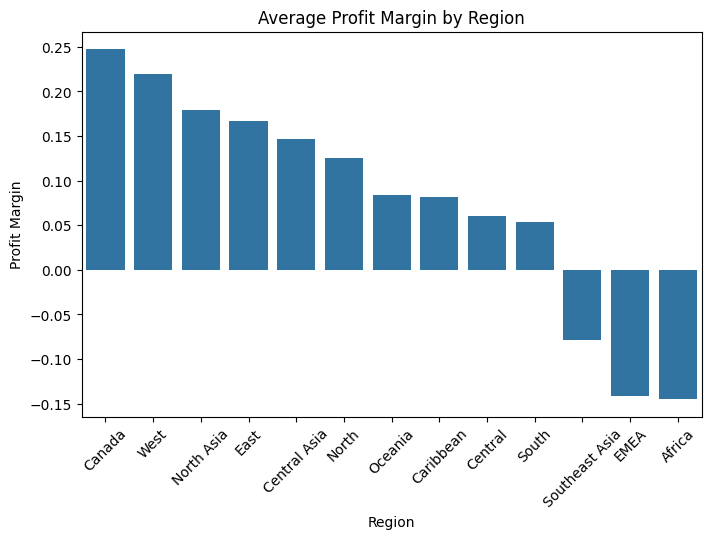

In [80]:
plt.figure(figsize=(8,5))
sns.barplot(x=region_margin.index, y=region_margin.values)
plt.title("Average Profit Margin by Region")
plt.ylabel("Profit Margin")
plt.xlabel("Region")
plt.xticks(rotation=45) 
plt.show()

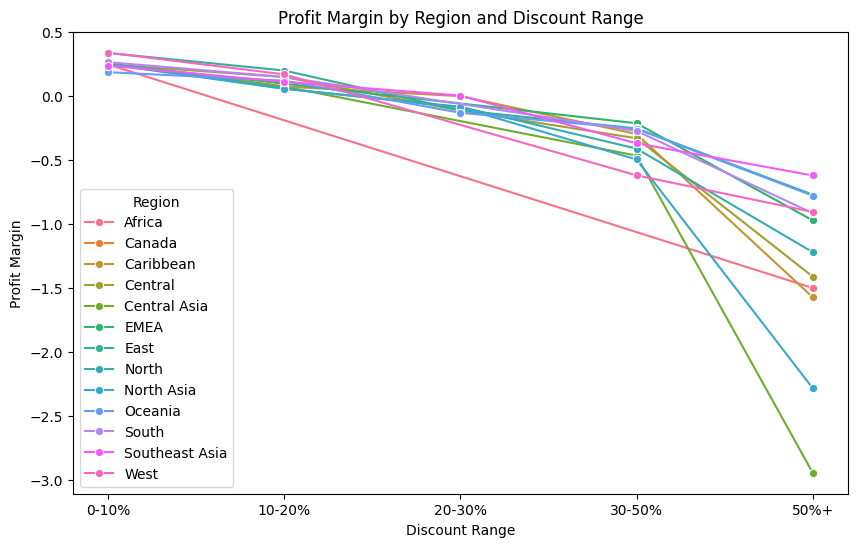

In [81]:
plt.figure(figsize=(10,6))
sns.lineplot(data=region_discount_margin, x="Discount_Bin", y="Profit_Margin", hue="Region", marker="o")
plt.title("Profit Margin by Region and Discount Range")
plt.ylabel("Profit Margin")
plt.xlabel("Discount Range")
plt.show()

In [82]:
region_summary = df.groupby("Region")[["Sales", "Profit"]].sum()
region_summary["Profit_Margin"] = region_summary["Profit"] / region_summary["Sales"]
region_summary.sort_values(by="Sales", ascending=False)

,Sales,Profit,Profit_Margin
Region,,,
Central,2822399,311403.98164,0.110333
South,1600960,140355.76618,0.087670
North,1248192,194597.95252,0.155904
Oceania,1100207,120089.11200,0.109151
Southeast Asia,884438,17852.32900,0.020185
North Asia,848349,165578.42100,0.195177
EMEA,806184,43897.97100,0.054452
Africa,783776,88871.63100,0.113389
Central Asia,752839,132480.18700,0.175974


In [83]:
#Selecting regions with high sales but low profit margin (A mismatch between sales and profitability)
mismatch = region_summary[(region_summary["Sales"] > region_summary["Sales"].median()) & 
                          (region_summary["Profit_Margin"] < region_summary["Profit_Margin"].median())]
mismatch

,Sales,Profit,Profit_Margin
Region,,,
Central,2822399,311403.98164,0.110333
Oceania,1100207,120089.11200,0.109151
South,1600960,140355.76618,0.087670
Southeast Asia,884438,17852.32900,0.020185


In [84]:
region_summary["Margin_Rank"] = region_summary["Profit_Margin"].rank(ascending=False)
region_summary.sort_values("Margin_Rank")

,Sales,Profit,Profit_Margin,Margin_Rank
Region,,,,
Canada,66932,17817.39000,0.266201,1.0
North Asia,848349,165578.42100,0.195177,2.0
Central Asia,752839,132480.18700,0.175974,3.0
North,1248192,194597.95252,0.155904,4.0
West,725514,108418.44890,0.149437,5.0
East,678834,91522.78000,0.134824,6.0
Africa,783776,88871.63100,0.113389,7.0
Central,2822399,311403.98164,0.110333,8.0
Oceania,1100207,120089.11200,0.109151,9.0


Southeast Asia is:
Mid-to-high in Sales (884k)
Dead last in Profit Margin (2%)
Over 10 percentage points lower than top regions
Less than half of overall dataset average (4.7%)

In [85]:
df.groupby("Region")["Discount"].mean().sort_values(ascending=False)

Region
Southeast Asia    0.272077
EMEA              0.196083
Africa            0.156704
Oceania           0.153169
South             0.149050
East              0.145365
Central           0.138851
Caribbean         0.135751
West              0.109335
North             0.096056
Central Asia      0.067480
North Asia        0.048717
Canada            0.000000
Name: Discount, dtype: float64

In [86]:
#Category breakdown for Southeast Asia
df[df["Region"] == "Southeast Asia"].groupby("Category")[["Sales","Profit"]].sum()

,Sales,Profit
Category,,
Furniture,313391,-7269.7665
Office Supplies,241299,4173.2515
Technology,329748,20948.8440


In [87]:
#Average shipping cost by region
df.groupby("Region")["Shipping.Cost"].mean().sort_values(ascending=False)

Region
North Asia        40.646112
Central Asia      38.003003
Oceania           34.593780
Southeast Asia    29.937950
North             27.475997
Central           26.710363
East              25.542001
South             25.353311
West              23.887688
Caribbean         21.058802
Canada            19.285495
Africa            19.215058
EMEA              17.573221
Name: Shipping.Cost, dtype: float64

Shipping cost is NOT the highest in Southeast Asia. So shipping alone does not explain the 2% margin.

In [88]:
df.groupby("Region")["Discount"].mean().sort_values(ascending=False)

Region
Southeast Asia    0.272077
EMEA              0.196083
Africa            0.156704
Oceania           0.153169
South             0.149050
East              0.145365
Central           0.138851
Caribbean         0.135751
West              0.109335
North             0.096056
Central Asia      0.067480
North Asia        0.048717
Canada            0.000000
Name: Discount, dtype: float64

Identified Southeast Asia as the lowest-performing region (2% margin), driven primarily by significantly higher average discount rates (27%) compared to top-performing regions (<7%). Findings suggest pricing strategy optimization opportunities to improve regional profitability.

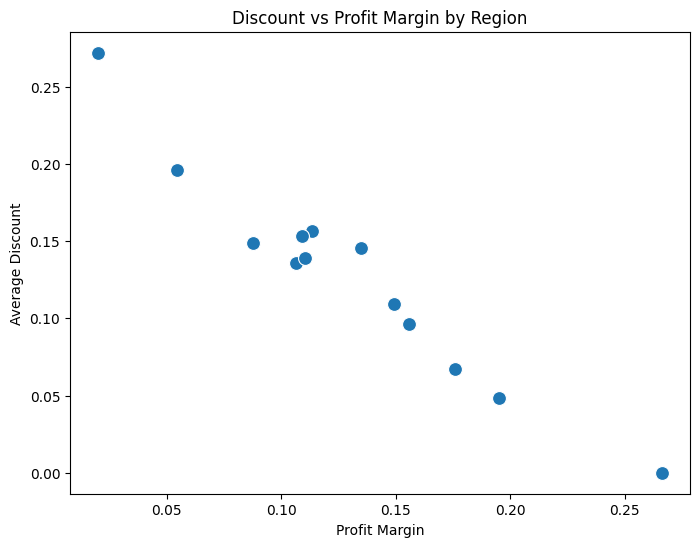

In [89]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=region_summary["Profit_Margin"], 
                y=df.groupby("Region")["Discount"].mean(),
                s=100)

plt.xlabel("Profit Margin")
plt.ylabel("Average Discount")
plt.title("Discount vs Profit Margin by Region")
plt.show()

In [90]:
region_summary = df.groupby("Region").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Discount": "mean"
})

region_summary["Profit_Margin"] = region_summary["Profit"] / region_summary["Sales"]

region_summary = region_summary.reset_index()
region_summary

,Region,Sales,Profit,Discount,Profit_Margin
0,Africa,783776,88871.63100,0.156704,0.113389
1,Canada,66932,17817.39000,0.000000,0.266201
2,Caribbean,324281,34571.32104,0.135751,0.106609
3,Central,2822399,311403.98164,0.138851,0.110333
4,Central Asia,752839,132480.18700,0.067480,0.175974
5,EMEA,806184,43897.97100,0.196083,0.054452
6,East,678834,91522.78000,0.145365,0.134824
7,North,1248192,194597.95252,0.096056,0.155904
8,North Asia,848349,165578.42100,0.048717,0.195177
9,Oceania,1100207,120089.11200,0.153169,0.109151


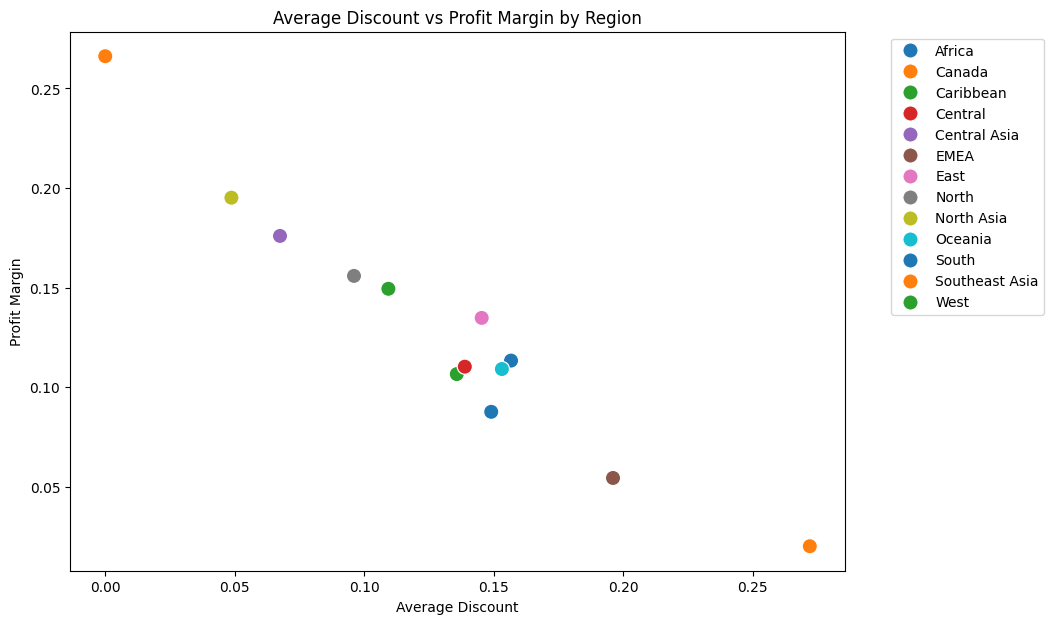

In [91]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=region_summary,
    x="Discount",
    y="Profit_Margin",
    hue="Region",
    palette="tab10",
    s=120
)

plt.title("Average Discount vs Profit Margin by Region")
plt.xlabel("Average Discount")
plt.ylabel("Profit Margin")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Linear Regression

In [92]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [93]:
X = df[["Discount"]]     # predictor 
y = df["Profit_Margin"]  # target

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [95]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [97]:
#how much profit margin changes for each increase in discount
model.coef_

array([-1.85844486])

In [98]:
model.intercept_

np.float64(0.31328252239164767)

In [99]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

r2, mse

(0.7174372824869168, 0.062278039235352)

R^2: 71.7% of the variation in profit margin is explained by disocunt alone. Which is very high for a single-variable business model. 

MSE: 0.062 error is relatively small compared to the spread of -4.7 to +0.58


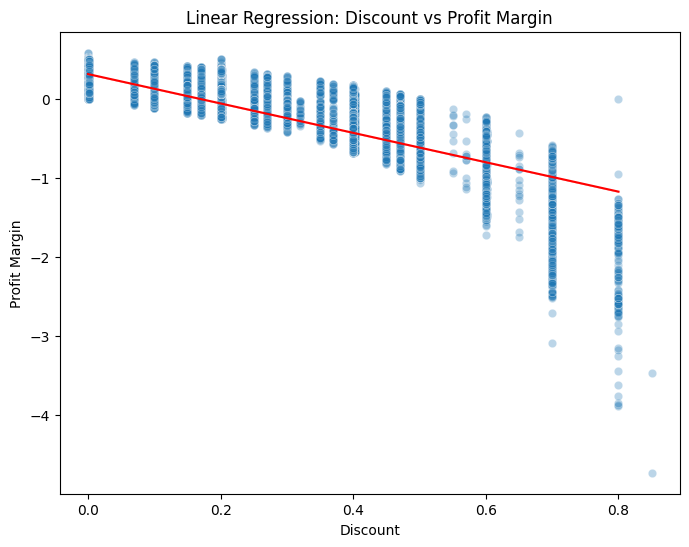

In [100]:
plt.figure(figsize=(8,6))

sns.scatterplot(x=df["Discount"], y=df["Profit_Margin"], alpha=0.3)

sns.lineplot(
    x=X_test["Discount"],
    y=y_pred,
    color="red"
)

plt.title("Linear Regression: Discount vs Profit Margin")
plt.xlabel("Discount")
plt.ylabel("Profit Margin")
plt.show()